<a href="https://colab.research.google.com/github/jcmachicao/knowledge_engineering/blob/main/U2__Ejemplo_Medicina_ACTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACT-R: Sistema de Diagnóstico Médico Simplificado
==================================================

Este ejemplo ilustra los conceptos clave de ACT-R:
- Memoria Declarativa (chunks de conocimiento)
- Memoria Procedural (reglas de producción)
- Activación y recuperación de memoria
- Ciclo cognitivo básico

Escenario: Un médico diagnostica síntomas comunes

In [2]:
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Optional

Aquí se usan 3 componentes cognitivos:
* Componente 1: Memoria Declarativa
* Componente 2: Memoria Procedimiental
* Componente 3: Arquitectura Cognitiva ACT-R

In [3]:
# ============================================================================
# COMPONENTE 1: MEMORIA DECLARATIVA (Chunks)
# ============================================================================

@dataclass
class Chunk:
    """Representa una unidad de conocimiento en memoria declarativa"""
    name: str
    chunk_type: str
    slots: Dict[str, str]
    activation: float = 0.0
    base_activation: float = 0.0
    uses: int = 0

    def __repr__(self):
        return f"Chunk({self.name}, type={self.chunk_type}, act={self.activation:.2f})"


class DeclarativeMemory:
    """Memoria Declarativa de ACT-R"""

    def __init__(self, decay_rate=0.5, noise=0.25):
        self.chunks: List[Chunk] = []
        self.decay_rate = decay_rate  # Parámetro d en ACT-R
        self.noise = noise
        self.time = 0

    def add_chunk(self, chunk: Chunk):
        """Añade un chunk a la memoria"""
        self.chunks.append(chunk)

    def retrieve(self, chunk_type: str, constraints: Dict[str, str]) -> Optional[Chunk]:
        """
        Recupera un chunk basado en tipo y restricciones.
        Simula el proceso de activación y threshold de ACT-R.
        """
        candidates = []

        for chunk in self.chunks:
            if chunk.chunk_type == chunk_type:
                # Verificar si cumple las restricciones
                matches = all(
                    chunk.slots.get(key) == value
                    for key, value in constraints.items()
                )
                if matches:
                    candidates.append(chunk)

        if not candidates:
            return None

        # Calcular activación para cada candidato
        for chunk in candidates:
            chunk.activation = self._calculate_activation(chunk)

        # Retornar el chunk con mayor activación (si supera threshold)
        best_chunk = max(candidates, key=lambda c: c.activation)
        threshold = -0.5  # Threshold típico en ACT-R

        if best_chunk.activation > threshold:
            best_chunk.uses += 1
            return best_chunk

        return None

    def _calculate_activation(self, chunk: Chunk) -> float:
        """
        Calcula la activación de un chunk según ACT-R:
        Activation = BaseLevel + Noise
        BaseLevel = ln(sum(t_i^-d)) donde t_i es tiempo desde uso i
        """
        # Activación base (simplificada)
        if chunk.uses > 0:
            base_level = math.log(chunk.uses + 1) - self.decay_rate * self.time
        else:
            base_level = chunk.base_activation

        # Añadir ruido logístico
        noise_value = random.uniform(-self.noise, self.noise)

        return base_level + noise_value

In [4]:
# ============================================================================
# COMPONENTE 2: MEMORIA PROCEDURAL (Reglas de Producción)
# ============================================================================

class ProductionRule:
    """Representa una regla de producción (IF-THEN)"""

    def __init__(self, name: str, conditions: callable, actions: callable, utility: float = 1.0):
        self.name = name
        self.conditions = conditions  # Función que retorna bool
        self.actions = actions  # Función que ejecuta acciones
        self.utility = utility  # Para conflict resolution

    def matches(self, state: Dict) -> bool:
        """Verifica si las condiciones se cumplen"""
        return self.conditions(state)

    def fire(self, state: Dict, memory: DeclarativeMemory) -> Dict:
        """Ejecuta las acciones de la regla"""
        print(f"  → Ejecutando regla: {self.name}")
        return self.actions(state, memory)

In [5]:
# ============================================================================
# COMPONENTE 3: ARQUITECTURA ACT-R COMPLETA
# ============================================================================

class ACTRArchitecture:
    """Arquitectura cognitiva ACT-R simplificada"""

    def __init__(self):
        self.declarative_memory = DeclarativeMemory()
        self.production_rules: List[ProductionRule] = []
        self.goal_buffer = {}
        self.retrieval_buffer = None
        self.cycle_count = 0

    def add_knowledge(self, chunks: List[Chunk]):
        """Añade conocimiento declarativo"""
        for chunk in chunks:
            self.declarative_memory.add_chunk(chunk)

    def add_production_rule(self, rule: ProductionRule):
        """Añade una regla de producción"""
        self.production_rules.append(rule)

    def set_goal(self, goal: Dict):
        """Establece el objetivo actual"""
        self.goal_buffer = goal

    def run(self, max_cycles=20):
        """Ejecuta el ciclo cognitivo de ACT-R"""
        print("\n" + "="*60)
        print("INICIANDO CICLO COGNITIVO ACT-R")
        print("="*60)

        while self.cycle_count < max_cycles and not self.goal_buffer.get('complete'):
            self.cycle_count += 1
            print(f"\n--- Ciclo {self.cycle_count} ---")
            print(f"Estado objetivo: {self.goal_buffer}")

            # Conflict resolution: encontrar reglas que coincidan
            matching_rules = [
                rule for rule in self.production_rules
                if rule.matches(self._get_state())
            ]

            if not matching_rules:
                print("  ✗ No hay reglas aplicables. Fin.")
                break

            # Seleccionar regla con mayor utilidad
            selected_rule = max(matching_rules, key=lambda r: r.utility)

            # Ejecutar la regla
            self.goal_buffer = selected_rule.fire(self._get_state(), self.declarative_memory)

            self.declarative_memory.time += 1

        print("\n" + "="*60)
        print(f"CICLO COMPLETADO - Total de ciclos: {self.cycle_count}")
        print("="*60)

    def _get_state(self) -> Dict:
        """Obtiene el estado actual del sistema"""
        return {
            'goal': self.goal_buffer,
            'retrieval': self.retrieval_buffer
        }

# Resumen de Componentes ACT-R

Aquí se resumen los tres componentes principales de la arquitectura ACT-R simplificada implementada:

1.  **Memoria Declarativa (`DeclarativeMemory`)**:
    *   Almacena unidades de conocimiento (`Chunk`).
    *   Cada `Chunk` tiene un nombre, tipo y ranuras (slots) con pares clave-valor.
    *   Simula la activación de la memoria, donde la activación depende del uso reciente y la frecuencia (`base_activation`, `uses`, `decay_rate`).
    *   Permite la recuperación de chunks basada en tipo y restricciones (`retrieve`).
    *   Incluye un parámetro de ruido (`noise`) para simular la variabilidad humana en la recuperación.

2.  **Memoria Procedural (`ProductionRule`)**:
    *   Contiene reglas de producción en formato IF-THEN.
    *   Cada regla tiene condiciones (`conditions`) que deben cumplirse y acciones (`actions`) a ejecutar.
    *   Tiene una utilidad (`utility`) que se usa en la resolución de conflictos para seleccionar la regla a ejecutar cuando varias coinciden.

3.  **Arquitectura Cognitiva ACT-R (`ACTRArchitecture`)**:
    *   Integra la Memoria Declarativa y la Memoria Procedural.
    *   Tiene un búfer de objetivo (`goal_buffer`) que representa la tarea actual o el estado deseado.
    *   Tiene un búfer de recuperación (`retrieval_buffer`) donde se coloca la información recuperada de la memoria declarativa.
    *   Ejecuta un ciclo cognitivo (`run`) donde se evalúan las reglas de producción, se selecciona una que coincida con el estado actual (incluyendo el objetivo y el búfer de recuperación), y se ejecutan sus acciones, modificando el estado del sistema.

In [6]:
# ============================================================================
# APLICACIÓN: DIAGNÓSTICO MÉDICO
# ============================================================================

def create_medical_knowledge() -> List[Chunk]:
    """Crea base de conocimiento médico"""

    knowledge = [
        # Conocimiento sobre enfermedades
        Chunk(
            name="gripe-info",
            chunk_type="enfermedad",
            slots={
                "nombre": "gripe",
                "sintoma1": "fiebre",
                "sintoma2": "tos",
                "sintoma3": "dolor_muscular",
                "tratamiento": "reposo_y_fluidos"
            },
            base_activation=1.5  # Enfermedad común, alta activación
        ),
        Chunk(
            name="covid-info",
            chunk_type="enfermedad",
            slots={
                "nombre": "covid-19",
                "sintoma1": "fiebre",
                "sintoma2": "tos",
                "sintoma3": "perdida_olfato",
                "tratamiento": "aislamiento_y_monitoreo"
            },
            base_activation=1.8  # Muy relevante recientemente
        ),
        Chunk(
            name="alergia-info",
            chunk_type="enfermedad",
            slots={
                "nombre": "alergia",
                "sintoma1": "estornudos",
                "sintoma2": "congestion",
                "sintoma3": "ojos_llorosos",
                "tratamiento": "antihistaminicos"
            },
            base_activation=1.2
        ),
        Chunk(
            name="migrana-info",
            chunk_type="enfermedad",
            slots={
                "nombre": "migraña",
                "sintoma1": "dolor_cabeza",
                "sintoma2": "nauseas",
                "sintoma3": "sensibilidad_luz",
                "tratamiento": "analgésicos_y_reposo"
            },
            base_activation=1.0
        ),

        # Conocimiento sobre síntomas
        Chunk(
            name="fiebre-caracteristica",
            chunk_type="sintoma",
            slots={
                "nombre": "fiebre",
                "severidad": "alta",
                "indicador": "infeccion"
            },
            base_activation=1.0
        ),
        Chunk(
            name="tos-caracteristica",
            chunk_type="sintoma",
            slots={
                "nombre": "tos",
                "severidad": "media",
                "indicador": "respiratorio"
            },
            base_activation=1.0
        ),
    ]

    return knowledge

Se crea un diagnóstico que tiene 4 reglas:
* Inicia el diagnóstico
* Busca la patología por síntoma principal
* Verifica síntomas adicionales
* Recomienda tratamiento

In [7]:
def create_diagnostic_rules(actr: ACTRArchitecture):
    """Crea las reglas de producción para diagnóstico"""

    # REGLA 1: Iniciar diagnóstico
    def inicio_conditions(state):
        return state['goal'].get('fase') == 'inicio'

    def inicio_actions(state, memory):
        print("  • Iniciando proceso de diagnóstico")
        print(f"  • Síntomas del paciente: {state['goal']['sintomas']}")
        return {
            'fase': 'buscar_enfermedad',
            'sintomas': state['goal']['sintomas'],
            'sintomas_analizados': []
        }

    actr.add_production_rule(
        ProductionRule("iniciar-diagnostico", inicio_conditions, inicio_actions, utility=2.0)
    )

    # REGLA 2: Buscar enfermedad por síntoma principal
    def buscar_conditions(state):
        goal = state['goal']
        return (goal.get('fase') == 'buscar_enfermedad' and
                len(goal.get('sintomas', [])) > 0)

    def buscar_actions(state, memory):
        sintoma_principal = state['goal']['sintomas'][0]
        print(f"  • Buscando enfermedades con síntoma: {sintoma_principal}")

        # Intentar recuperar enfermedad de memoria declarativa
        enfermedad = memory.retrieve(
            chunk_type="enfermedad",
            constraints={"sintoma1": sintoma_principal}
        )

        if enfermedad:
            print(f"  ✓ Enfermedad candidata recuperada: {enfermedad.name}")
            actr.retrieval_buffer = enfermedad
            return {
                'fase': 'verificar_sintomas',
                'sintomas': state['goal']['sintomas'],
                'candidato': enfermedad.slots['nombre'],
                'sintomas_analizados': [sintoma_principal]
            }
        else:
            print(f"  ✗ No se encontró enfermedad para {sintoma_principal}")
            return {
                'fase': 'diagnostico_desconocido',
                'sintomas': state['goal']['sintomas'],
                'complete': True
            }

    actr.add_production_rule(
        ProductionRule("buscar-por-sintoma", buscar_conditions, buscar_actions, utility=1.5)
    )

    # REGLA 3: Verificar síntomas adicionales
    def verificar_conditions(state):
        return state['goal'].get('fase') == 'verificar_sintomas'

    def verificar_actions(state, memory):
        enfermedad = actr.retrieval_buffer
        sintomas_paciente = set(state['goal']['sintomas'])
        sintomas_enfermedad = {
            enfermedad.slots.get('sintoma1'),
            enfermedad.slots.get('sintoma2'),
            enfermedad.slots.get('sintoma3')
        }
        sintomas_enfermedad.discard(None)

        coincidencias = sintomas_paciente.intersection(sintomas_enfermedad)
        confianza = len(coincidencias) / len(sintomas_enfermedad)

        print(f"  • Verificando síntomas adicionales...")
        print(f"  • Coincidencias: {coincidencias}")
        print(f"  • Confianza: {confianza:.2%}")

        if confianza >= 0.5:  # Threshold de confianza
            return {
                'fase': 'recomendar_tratamiento',
                'diagnostico': enfermedad.slots['nombre'],
                'confianza': confianza,
                'sintomas': state['goal']['sintomas']
            }
        else:
            return {
                'fase': 'diagnostico_incierto',
                'diagnostico': enfermedad.slots['nombre'],
                'confianza': confianza,
                'complete': True
            }

    actr.add_production_rule(
        ProductionRule("verificar-sintomas", verificar_conditions, verificar_actions, utility=1.0)
    )

    # REGLA 4: Recomendar tratamiento
    def recomendar_conditions(state):
        return state['goal'].get('fase') == 'recomendar_tratamiento'

    def recomendar_actions(state, memory):
        enfermedad = actr.retrieval_buffer
        tratamiento = enfermedad.slots.get('tratamiento', 'consultar_especialista')

        print(f"  ✓ DIAGNÓSTICO FINAL: {state['goal']['diagnostico']}")
        print(f"  ✓ Confianza: {state['goal']['confianza']:.2%}")
        print(f"  ✓ Tratamiento recomendado: {tratamiento}")

        return {
            'fase': 'completo',
            'diagnostico': state['goal']['diagnostico'],
            'tratamiento': tratamiento,
            'complete': True
        }

    actr.add_production_rule(
        ProductionRule("recomendar-tratamiento", recomendar_conditions, recomendar_actions, utility=1.0)
    )

# Reglas de Diagnóstico en Términos Médicos

Las reglas de producción implementadas simulan un proceso de razonamiento diagnóstico simplificado, similar a cómo un médico abordaría un caso:

1.  **`iniciar-diagnostico` (Fase: Inicio)**: Esta regla representa el momento inicial donde el médico **recoge la información básica del paciente**, como los síntomas principales que presenta. Es el punto de partida para el proceso mental de diagnóstico.

2.  **`buscar-por-sintoma` (Fase: Buscar enfermedad)**: Una vez que el médico tiene los síntomas iniciales (ej. fiebre), esta regla simula el proceso de **buscar en su memoria o base de conocimiento** (Memoria Declarativa) **posibles enfermedades** que se manifiestan con ese síntoma principal. Si encuentra una o más candidatas, selecciona la más probable (basado en la activación) para considerarla.

3.  **`verificar-sintomas` (Fase: Verificar síntomas)**: Con una enfermedad candidata en mente (ej. gripe), esta regla simula la **evaluación de los síntomas adicionales** del paciente para ver si coinciden con los síntomas característicos de la enfermedad candidata almacenados en la memoria. Se calcula un nivel de "confianza" o certeza basado en cuántos síntomas coinciden, como si el médico estuviera confirmando su hipótesis diagnóstica.

4.  **`recomendar-tratamiento` (Fase: Recomendar tratamiento)**: Si la confianza en el diagnóstico candidato es suficiente, esta regla simula el paso final donde el médico **llega a una conclusión diagnóstica** (ej. gripe) y **recupera de su memoria el tratamiento asociado** a esa enfermedad para recomendárselo al paciente.

In [8]:
# ============================================================================
# DEMOSTRACIÓN
# ============================================================================

def main():
    print("\n" + "="*70)
    print(" ACT-R: SISTEMA DE DIAGNÓSTICO MÉDICO")
    print("="*70)
    print("\nEste ejemplo demuestra:")
    print("  1. Memoria Declarativa con chunks de conocimiento médico")
    print("  2. Memoria Procedural con reglas de diagnóstico")
    print("  3. Activación y recuperación de memoria")
    print("  4. Ciclo cognitivo básico de ACT-R")

    # Crear arquitectura
    actr = ACTRArchitecture()

    # Añadir conocimiento médico
    knowledge = create_medical_knowledge()
    actr.add_knowledge(knowledge)

    print(f"\n✓ Cargados {len(knowledge)} chunks en memoria declarativa")

    # Crear reglas de diagnóstico
    create_diagnostic_rules(actr)
    print(f"✓ Cargadas {len(actr.production_rules)} reglas de producción")

    # CASO 1: Paciente con gripe
    print("\n" + "="*70)
    print("CASO 1: Paciente con síntomas de gripe")
    print("="*70)

    actr.set_goal({
        'fase': 'inicio',
        'sintomas': ['fiebre', 'tos', 'dolor_muscular']
    })
    actr.run(max_cycles=10)

    # CASO 2: Paciente con COVID
    print("\n\n" + "="*70)
    print("CASO 2: Paciente con síntomas de COVID-19")
    print("="*70)

    actr.cycle_count = 0
    actr.goal_buffer = {}
    actr.set_goal({
        'fase': 'inicio',
        'sintomas': ['fiebre', 'tos', 'perdida_olfato']
    })
    actr.run(max_cycles=10)

    # CASO 3: Síntomas ambiguos
    print("\n\n" + "="*70)
    print("CASO 3: Síntomas ambiguos")
    print("="*70)

    actr.cycle_count = 0
    actr.goal_buffer = {}
    actr.set_goal({
        'fase': 'inicio',
        'sintomas': ['fiebre', 'nauseas']
    })
    actr.run(max_cycles=10)

    print("\n" + "="*70)
    print("EJERCICIOS PROPUESTOS PARA ESTUDIANTES:")
    print("="*70)
    print("""
1. Añadir nuevas enfermedades y síntomas a la base de conocimiento
2. Modificar los parámetros de activación (decay_rate, noise) y observar efectos
3. Implementar aprendizaje: aumentar base_activation de chunks usados frecuentemente
4. Añadir una regla para preguntar por síntomas adicionales al paciente
5. Implementar spreading activation entre chunks relacionados
6. Crear un mecanismo para manejar síntomas contradictorios
7. Añadir tiempos de latencia realistas en las recuperaciones de memoria
    """)

In [9]:
# Crear un chunk simple
mi_chunk = Chunk(
    name="gripe-conocimiento",
    chunk_type="enfermedad",
    slots={
        "nombre": "gripe",
        "sintoma1": "fiebre",
        "sintoma2": "tos",
        "tratamiento": "reposo"
    },
    base_activation=1.0
)

print(mi_chunk)
print(f"Activación: {mi_chunk.activation}")
print(f"Slots: {mi_chunk.slots}")

Chunk(gripe-conocimiento, type=enfermedad, act=0.00)
Activación: 0.0
Slots: {'nombre': 'gripe', 'sintoma1': 'fiebre', 'sintoma2': 'tos', 'tratamiento': 'reposo'}


In [10]:
# Crear memoria declarativa con parámetros personalizados
memoria = DeclarativeMemory(
    decay_rate=0.5,  # Velocidad de olvido (mayor = olvido más rápido)
    noise=0.25       # Ruido en activación (mayor = más variabilidad)
)

# Añadir chunks
memoria.add_chunk(mi_chunk)

# Recuperar chunk
resultado = memoria.retrieve(
    chunk_type="enfermedad",
    constraints={"sintoma1": "fiebre"}
)
print(f"Chunk recuperado: {resultado}")

Chunk recuperado: Chunk(gripe-conocimiento, type=enfermedad, act=1.16)


In [11]:
# Definir condiciones
def mi_condicion(state):
    return state['goal'].get('fase') == 'diagnostico'

# Definir acciones
def mi_accion(state, memory):
    print("Ejecutando mi regla personalizada")
    return {'fase': 'siguiente_paso'}

# Crear regla
mi_regla = ProductionRule(
    name="mi-regla-diagnostico",
    conditions=mi_condicion,
    actions=mi_accion,
    utility=1.0
)


Probando decay_rate = 0.1
  Tiempo 0: Activación = 1.000
  Tiempo 1: Activación = 1.000
  Tiempo 2: Activación = 1.000
  Tiempo 3: Activación = 1.000
  Tiempo 4: Activación = 1.000
  Tiempo 5: Activación = 1.000
  Tiempo 6: Activación = 1.000
  Tiempo 7: Activación = 1.000
  Tiempo 8: Activación = 1.000
  Tiempo 9: Activación = 1.000

Probando decay_rate = 0.3
  Tiempo 0: Activación = 1.000
  Tiempo 1: Activación = 1.000
  Tiempo 2: Activación = 1.000
  Tiempo 3: Activación = 1.000
  Tiempo 4: Activación = 1.000
  Tiempo 5: Activación = 1.000
  Tiempo 6: Activación = 1.000
  Tiempo 7: Activación = 1.000
  Tiempo 8: Activación = 1.000
  Tiempo 9: Activación = 1.000

Probando decay_rate = 0.5
  Tiempo 0: Activación = 1.000
  Tiempo 1: Activación = 1.000
  Tiempo 2: Activación = 1.000
  Tiempo 3: Activación = 1.000
  Tiempo 4: Activación = 1.000
  Tiempo 5: Activación = 1.000
  Tiempo 6: Activación = 1.000
  Tiempo 7: Activación = 1.000
  Tiempo 8: Activación = 1.000
  Tiempo 9: Activaci

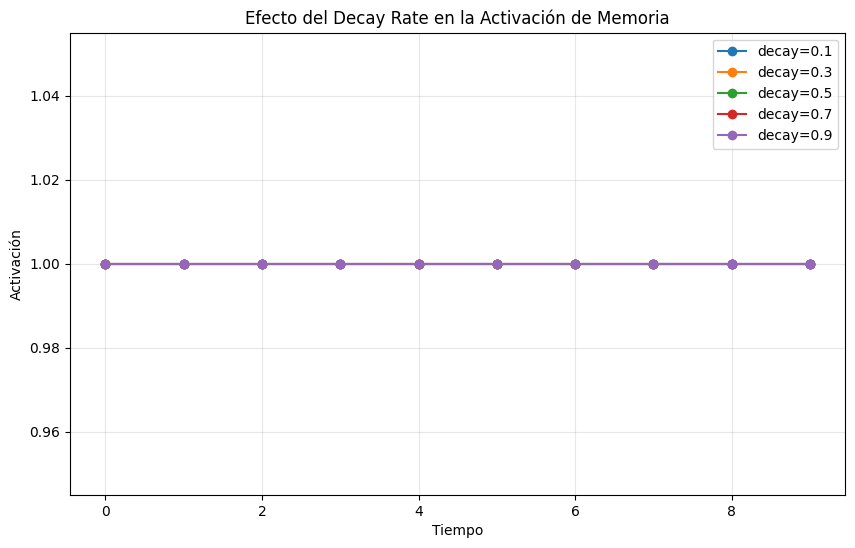


📊 INTERPRETACIÓN:
- Mayor decay → Olvido más rápido (activación baja más rápido)
- Menor decay → Memoria más persistente


In [12]:
import matplotlib.pyplot as plt

def experimento_decay():
    """Experimenta con diferentes tasas de decay"""

    decay_rates = [0.1, 0.3, 0.5, 0.7, 0.9]
    resultados = []

    for decay in decay_rates:
        print(f"\n{'='*50}")
        print(f"Probando decay_rate = {decay}")
        print('='*50)

        # Crear memoria con este decay
        memoria = DeclarativeMemory(decay_rate=decay, noise=0.0)

        # Añadir conocimiento
        chunk = Chunk(
            name="test-chunk",
            chunk_type="enfermedad",
            slots={"sintoma1": "fiebre"},
            base_activation=1.0
        )
        memoria.add_chunk(chunk)

        # Simular paso del tiempo
        activaciones = []
        for tiempo in range(10):
            memoria.time = tiempo
            chunk.activation = memoria._calculate_activation(chunk)
            activaciones.append(chunk.activation)
            print(f"  Tiempo {tiempo}: Activación = {chunk.activation:.3f}")

        resultados.append(activaciones)

    # Graficar resultados
    plt.figure(figsize=(10, 6))
    for i, decay in enumerate(decay_rates):
        plt.plot(range(10), resultados[i], marker='o', label=f'decay={decay}')

    plt.xlabel('Tiempo')
    plt.ylabel('Activación')
    plt.title('Efecto del Decay Rate en la Activación de Memoria')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n📊 INTERPRETACIÓN:")
    print("- Mayor decay → Olvido más rápido (activación baja más rápido)")
    print("- Menor decay → Memoria más persistente")

# Ejecutar experimento
experimento_decay()

In [13]:
def experimento_ruido():
    """Experimenta con diferentes niveles de ruido"""

    noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0]

    for noise in noise_levels:
        print(f"\n{'='*50}")
        print(f"Probando noise = {noise}")
        print('='*50)

        memoria = DeclarativeMemory(decay_rate=0.5, noise=noise)

        # Añadir dos chunks similares
        chunk1 = Chunk(
            name="enfermedad-A",
            chunk_type="enfermedad",
            slots={"sintoma1": "fiebre"},
            base_activation=1.0
        )
        chunk2 = Chunk(
            name="enfermedad-B",
            chunk_type="enfermedad",
            slots={"sintoma1": "fiebre"},
            base_activation=0.9  # Ligeramente menor
        )

        memoria.add_chunk(chunk1)
        memoria.add_chunk(chunk2)

        # Intentar recuperar múltiples veces
        recuperaciones = {"enfermedad-A": 0, "enfermedad-B": 0, "Fallo": 0}

        for _ in range(100):
            resultado = memoria.retrieve(
                chunk_type="enfermedad",
                constraints={"sintoma1": "fiebre"}
            )
            if resultado:
                recuperaciones[resultado.name] += 1
            else:
                recuperaciones["Fallo"] += 1

        print(f"  Resultados de 100 recuperaciones:")
        for nombre, conteo in recuperaciones.items():
            print(f"    {nombre}: {conteo}% veces")

    print("\n📊 INTERPRETACIÓN:")
    print("- Noise = 0.0 → Siempre se recupera el chunk con mayor activación")
    print("- Noise > 0.0 → Introduce variabilidad (más humano)")
    print("- Noise alto → Puede recuperar chunks subóptimos o fallar")

# Ejecutar experimento
experimento_ruido()


Probando noise = 0.0
  Resultados de 100 recuperaciones:
    enfermedad-A: 99% veces
    enfermedad-B: 1% veces
    Fallo: 0% veces

Probando noise = 0.1
  Resultados de 100 recuperaciones:
    enfermedad-A: 99% veces
    enfermedad-B: 1% veces
    Fallo: 0% veces

Probando noise = 0.25
  Resultados de 100 recuperaciones:
    enfermedad-A: 100% veces
    enfermedad-B: 0% veces
    Fallo: 0% veces

Probando noise = 0.5
  Resultados de 100 recuperaciones:
    enfermedad-A: 99% veces
    enfermedad-B: 1% veces
    Fallo: 0% veces

Probando noise = 1.0
  Resultados de 100 recuperaciones:
    enfermedad-A: 2% veces
    enfermedad-B: 98% veces
    Fallo: 0% veces

📊 INTERPRETACIÓN:
- Noise = 0.0 → Siempre se recupera el chunk con mayor activación
- Noise > 0.0 → Introduce variabilidad (más humano)
- Noise alto → Puede recuperar chunks subóptimos o fallar


In [14]:
def experimento_conocimiento():
    """Compara desempeño con diferentes bases de conocimiento"""

    # CONFIGURACIÓN 1: Conocimiento mínimo
    print("\n" + "="*60)
    print("CONFIGURACIÓN 1: Base de conocimiento MÍNIMA (2 enfermedades)")
    print("="*60)

    actr1 = ACTRArchitecture()

    conocimiento_minimo = [
        Chunk(
            name="gripe-info",
            chunk_type="enfermedad",
            slots={
                "nombre": "gripe",
                "sintoma1": "fiebre",
                "sintoma2": "tos",
                "tratamiento": "reposo"
            },
            base_activation=1.0
        ),
        Chunk(
            name="alergia-info",
            chunk_type="enfermedad",
            slots={
                "nombre": "alergia",
                "sintoma1": "estornudos",
                "sintoma2": "congestion",
                "tratamiento": "antihistaminicos"
            },
            base_activation=1.0
        )
    ]

    actr1.add_knowledge(conocimiento_minimo)
    create_diagnostic_rules(actr1)

    actr1.set_goal({
        'fase': 'inicio',
        'sintomas': ['fiebre', 'tos']
    })
    actr1.run(max_cycles=10)

    # CONFIGURACIÓN 2: Conocimiento extenso (usar create_medical_knowledge())
    print("\n" + "="*60)
    print("CONFIGURACIÓN 2: Base de conocimiento EXTENSA (4+ enfermedades)")
    print("="*60)

    actr2 = ACTRArchitecture()
    conocimiento_extenso = create_medical_knowledge()
    actr2.add_knowledge(conocimiento_extenso)
    create_diagnostic_rules(actr2)

    actr2.set_goal({
        'fase': 'inicio',
        'sintomas': ['fiebre', 'tos']
    })
    actr2.run(max_cycles=10)

    print("\n📊 INTERPRETACIÓN:")
    print("- Más conocimiento → Mayor precisión pero más ciclos de búsqueda")
    print("- Menos conocimiento → Más rápido pero puede fallar en casos complejos")

# Ejecutar experimento
experimento_conocimiento()


CONFIGURACIÓN 1: Base de conocimiento MÍNIMA (2 enfermedades)

INICIANDO CICLO COGNITIVO ACT-R

--- Ciclo 1 ---
Estado objetivo: {'fase': 'inicio', 'sintomas': ['fiebre', 'tos']}
  → Ejecutando regla: iniciar-diagnostico
  • Iniciando proceso de diagnóstico
  • Síntomas del paciente: ['fiebre', 'tos']

--- Ciclo 2 ---
Estado objetivo: {'fase': 'buscar_enfermedad', 'sintomas': ['fiebre', 'tos'], 'sintomas_analizados': []}
  → Ejecutando regla: buscar-por-sintoma
  • Buscando enfermedades con síntoma: fiebre
  ✓ Enfermedad candidata recuperada: gripe-info

--- Ciclo 3 ---
Estado objetivo: {'fase': 'verificar_sintomas', 'sintomas': ['fiebre', 'tos'], 'candidato': 'gripe', 'sintomas_analizados': ['fiebre']}
  → Ejecutando regla: verificar-sintomas
  • Verificando síntomas adicionales...
  • Coincidencias: {'fiebre', 'tos'}
  • Confianza: 100.00%

--- Ciclo 4 ---
Estado objetivo: {'fase': 'recomendar_tratamiento', 'diagnostico': 'gripe', 'confianza': 1.0, 'sintomas': ['fiebre', 'tos']}
  →